# Breakout Prediction — Exploratory Data Analysis

EDA on `breakout_features.csv`, generated from a month of daily Last.fm
trending-track snapshots (`ingest.py`) and the feature engineering in
`breakout_features.py`.

**Goal**: understand feature quality, missingness, and signal strength
before training the breakout-prediction model, and decide how to handle
gaps left by the data collection issues earlier in the month.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)

df = pd.read_csv("breakout_features.csv", parse_dates=["as_of_date"])
df.shape

(1084, 14)

## 1. Overview and missingness

In [2]:
df.dtypes

track_id                        int64
as_of_date             datetime64[us]
current_rank                    int64
rank_1d_ago                   float64
rank_3d_ago                   float64
rank_7d_ago                   float64
velocity_1d                   float64
velocity_3d                   float64
velocity_7d                   float64
acceleration                  float64
volatility_14d                float64
days_tracked_so_far             int64
n_sources_today                 int64
label                         float64
dtype: object

In [3]:
df.isna().sum()

track_id                 0
as_of_date               0
current_rank             0
rank_1d_ago            221
rank_3d_ago            339
rank_7d_ago            559
velocity_1d            221
velocity_3d            339
velocity_7d            559
acceleration           573
volatility_14d         289
days_tracked_so_far      0
n_sources_today          0
label                  495
dtype: int64

**Note**: `velocity_7d` and `acceleration` have the highest missingness
(52%/54%) -- this traces directly back to the ~18 of 36 calendar days
that were missing this month (cron issues while debugging iCloud sync,
DB Browser file locks, etc.), not a bug in the feature code. Any
lookback window longer than a few days is more likely to hit a gap.

## 2. Label balance

In [4]:
labeled = df.dropna(subset=["label"])
print(f"Total labeled rows: {len(labeled)} of {len(df)} total feature rows")
labeled["label"].value_counts(normalize=True)

Total labeled rows: 589 of 1084 total feature rows


label
0.0    0.539898
1.0    0.460102
Name: proportion, dtype: float64

Fairly balanced (~54%/46%) -- convenient, since class imbalance won't
be a major complication on top of everything else.

## 3. Feature means by label, and correlation with label

In [5]:
feature_cols = ["current_rank", "velocity_1d", "velocity_3d", "velocity_7d",
                "acceleration", "volatility_14d", "days_tracked_so_far", "n_sources_today"]

labeled.groupby("label")[feature_cols].mean()

,current_rank,velocity_1d,velocity_3d,velocity_7d,acceleration,volatility_14d,days_tracked_so_far,n_sources_today
label,,,,,,,,
0.0,30.072327,0.150183,0.296970,-0.513034,0.150298,5.791810,5.506289,1.490566
1.0,13.501845,1.690987,0.736246,-0.078818,0.191461,5.118607,6.173432,1.760148


In [6]:
corr = labeled[feature_cols + ["label"]].corr()["label"].drop("label").sort_values()
corr

current_rank          -0.562009
volatility_14d        -0.087539
acceleration           0.011348
velocity_3d            0.076621
days_tracked_so_far    0.092509
velocity_1d            0.144480
velocity_7d            0.147072
n_sources_today        0.276071
Name: label, dtype: float64

**Key finding**: `current_rank` is by far the strongest predictor
(-0.56) -- makes sense mechanically, a track already near the top is
closer to crossing the top-20 threshold. `n_sources_today` (whether a
track charts in both global AND US simultaneously) is a genuinely
useful secondary signal (+0.28) that wasn't part of the original plan.
Velocity features show the expected direction (positive correlation
with breaking out) but are weaker than hoped, likely diluted by their
high missingness rate.

## 4. Current rank vs. breakout outcome

In [7]:
bins = [0, 10, 20, 30, 40, 50]
bin_labels = ["1-10", "11-20", "21-30", "31-40", "41-50"]
labeled = labeled.copy()
labeled["rank_bin"] = pd.cut(labeled["current_rank"], bins=bins, labels=bin_labels)

pivot = labeled.groupby(["rank_bin", "label"]).size().unstack(fill_value=0)
pivot

label,0.0,1.0
rank_bin,,
1-10,28,140
11-20,68,61
21-30,48,44
31-40,89,20
41-50,85,6


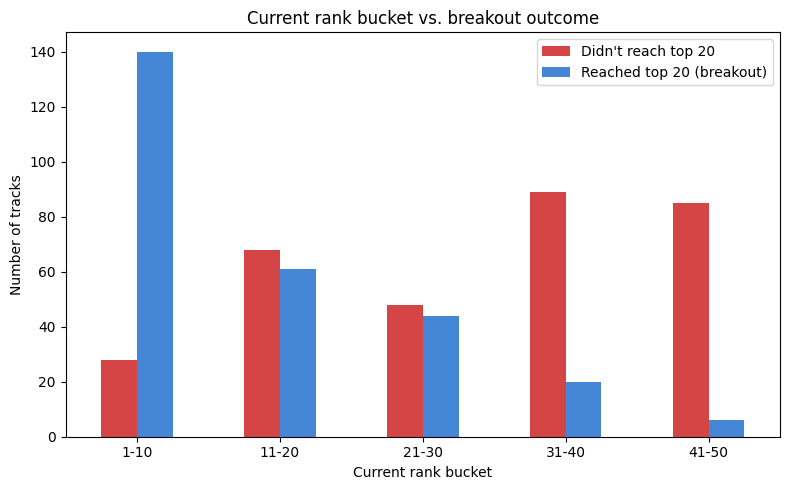

In [8]:
pivot.plot(kind="bar", figsize=(8, 5), color=["#d64545", "#4587d6"])
plt.title("Current rank bucket vs. breakout outcome")
plt.xlabel("Current rank bucket")
plt.ylabel("Number of tracks")
plt.xticks(rotation=0)
plt.legend(["Didn't reach top 20", "Reached top 20 (breakout)"])
plt.tight_layout()
plt.savefig("rank_vs_breakout.png", dpi=100)
plt.show()

Clear, expected pattern: 140 of 168 tracks starting in the top 10 went
on to hit top 20, versus only 6 of 91 tracks starting in the 41-50
range. Confirms `current_rank` alone carries a lot of the predictive
weight -- worth remembering when interpreting the trained model's
feature importances later; it shouldn't be surprising if this feature
dominates.

## 5. n_sources_today: charting in both charts vs. one

In [9]:
source_breakdown = labeled.groupby(["n_sources_today", "label"]).size().unstack(fill_value=0)
print(source_breakdown)
print()
print("Breakout rate by n_sources_today:")
print(labeled.groupby("n_sources_today")["label"].mean())

label            0.0  1.0
n_sources_today          
1                162   65
2                156  206

Breakout rate by n_sources_today:
n_sources_today
1    0.286344
2    0.569061
Name: label, dtype: float64


Tracks appearing in **both** the global and US charts on a given day
break out 57% of the time, versus 29% for tracks in just one chart.
This is a real, somewhat non-obvious signal -- simultaneous cross-chart
presence indicates broader momentum than either chart alone.

## 6. Missingness impact: how many rows have complete features?

In [10]:
complete = labeled.dropna(subset=["velocity_1d", "velocity_3d", "velocity_7d", "acceleration"])
print(f"{len(complete)} of {len(labeled)} labeled rows have ALL velocity + acceleration features present")
complete["label"].value_counts()

271 of 589 labeled rows have ALL velocity + acceleration features present


label
1.0    145
0.0    126
Name: count, dtype: int64

## 7. Decision: how to handle the missingness

Three options considered:

1. **Drop the sparse features** (`velocity_7d`, `acceleration`) -- keeps
   ~589 rows, but loses the trajectory-shape story.
2. **Restrict to complete rows only** -- keeps all features, but drops
   to 271 rows (over half the labeled data lost).
3. **Use LightGBM's native NaN handling** -- keeps all 589 rows AND all
   features; the model itself learns whether "this value is missing" is
   informative, rather than deciding upfront by dropping data.

**Decision: going with option 3.** It's the most defensible technical
choice given real-world data gaps, and it's a legitimate thing to
explain in an interview: the model handles missingness natively instead
of the data being artificially filled or discarded.

## Next step

Train a baseline (logistic regression) and a LightGBM model on
`breakout_features.csv`, split **by date** (not randomly) to avoid
leaking a track's future trajectory into training.